In [1]:
import os, sys
import pandas as pd
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload 1


# Point this to your SWJ repo root (the folder that contains orgpackage/, results/, data/, etc.)
#PROJECT_ROOT = os.path.expanduser("~/notebooks/SWJ")
#os.chdir(PROJECT_ROOT)
#if PROJECT_ROOT not in sys.path:
#    sys.path.append(PROJECT_ROOT)

from orgpackage.aux import load_dataset, load_experiments
from orgpackage.config import DOMAIN_CLASSES_CORR
from orgpackage.tester import build_correctness_table, stratified_permutation_test, run_permutation_tests, paired_permutation_test

In [2]:
data = load_dataset()

# Medical + administrative (medgov) split
train_medgov_full, test_medgov = train_test_split(data, test_size=0.5, random_state=42)
train_medgov, val_medgov = train_test_split(train_medgov_full, test_size=0.5, random_state=42)

# Education split (different proportions)
train_edu_full, test_edu = train_test_split(data, test_size=0.2, random_state=42)
train_edu, val_edu = train_test_split(train_edu_full, test_size=0.5, random_state=42)

tests = {
    "medical": test_medgov,
    "administrative": test_medgov,
    "education": test_edu,
}


corr_table_med = build_correctness_table('medical', test_medgov, 'rules')
corr_table_adm = build_correctness_table('administrative', test_medgov, 'rules')
corr_table_edu = build_correctness_table('education', test_edu, 'rules')

instance_to_country = data.set_index("instance")["country"]

corr_table_med["country"] = corr_table_med.index.map(instance_to_country)
corr_table_adm["country"] = corr_table_adm.index.map(instance_to_country)
corr_table_edu["country"] = corr_table_edu.index.map(instance_to_country)


correctness_tables = {
    "med": corr_table_med,
    "adm": corr_table_adm,
    "edu": corr_table_edu,
}

# Small preview instead of the full 90k+ rows
display(corr_table_med.head())

Loaded dataset with 182519 unique instances


,med-r-expert-0,med-r-llm-0,med-r-counter-0,med-r-counter-1,med-r-counter-2,med-r-counter-3,med-r-counter-4,med-r-counter-5,med-r-idf-0,med-r-idf-1,med-r-idf-2,med-r-idf-3,med-r-idf-4,med-r-idf-5,country
instance,,,,,,,,,,,,,,,
http://www.wikidata.org/entity/Q111877988,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Q213
http://www.wikidata.org/entity/Q92061604,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Q142
http://www.wikidata.org/entity/Q42409359,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Q183
http://www.wikidata.org/entity/Q104928893,0,1,1,1,1,1,1,1,1,1,1,1,1,1,Q142
http://www.wikidata.org/entity/Q105022178,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Q142


## 1. Nested Structure vs 3 classes

In [3]:
nested_vs_3class_pairs = [
    ("med-r-counter-0", "med-r-counter-3"),  # counter, no preprocessing
    ("med-r-counter-1", "med-r-counter-4"),  # counter, spacy
    ("med-r-counter-2", "med-r-counter-5"),  # counter, decomposition
    ("med-r-idf-0", "med-r-idf-3"),  # idf, no preprocessing
    ("med-r-idf-1", "med-r-idf-4"),  # idf, spacy
    ("med-r-idf-2", "med-r-idf-5"),  # idf, decomposition
]

In [ ]:
strata = []
for exp_sim, exp_nested in nested_vs_3class_pairs:
    stratum = corr_table_med[[exp_sim, exp_nested]].rename(
        columns={exp_sim: "3 classes", exp_nested: "nested classes"}
    )
    strata.append(stratum)

# Run the test (one-sided: is nested > simultaneous?)
obs, p_val = stratified_permutation_test(
    strata=strata,
    exp_a="3 classes",
    exp_b="nested classes",
    n_perm=10_000,
    random_state=42,
    statistic="pooled",  # weighted by entity count, all strata same size anyway
)

print(f"Nested vs Simultaneous: diff={obs:+.4f}, p={p_val:.4f}")

Nested vs Simultaneous: diff=-0.0049, p=0.0001


In [5]:
results = run_permutation_tests(
    correctness=corr_table_med,
    pairs=nested_vs_3class_pairs,
    n_perm=10_000,
    correction="holm",
)
print(results.sort_values("obs_diff"))

             exp_a            exp_b  obs_diff  p_value  p_corrected  \
5      med-r-idf-2      med-r-idf-5 -0.008196   0.0001       0.0006   
1  med-r-counter-1  med-r-counter-4 -0.007090   0.0001       0.0006   
0  med-r-counter-0  med-r-counter-3 -0.006673   0.0001       0.0006   
3      med-r-idf-0      med-r-idf-3 -0.005095   0.0001       0.0006   
4      med-r-idf-1      med-r-idf-4 -0.004219   0.0001       0.0006   
2  med-r-counter-2  med-r-counter-5  0.002126   0.0001       0.0006   

   significant  
5         True  
1         True  
0         True  
3         True  
4         True  
2         True  


## 2. Preprocessing

In [ ]:
# Pairs are (no preprocessing, spaCy); exp_a is "none" and exp_b is "spacy" for each domain.
preprocessing_pairs = [
    ("med-r-counter-3", "med-r-counter-4", 'med'),  # medical, counter: no preprocessing vs spacy
    ("med-r-idf-3", "med-r-idf-4", 'med'),  # medical, counter: no preprocessing vs spacy
    ("adm-r-counter-0", "adm-r-counter-1", 'adm'),   # administration, counter: no preprocessing vs spacy
    ("adm-r-idf-0", "adm-r-idf-1", 'adm'),  # administration, counter: no preprocessing vs spacy
    ("edu-r-counter-0", "edu-r-counter-1", 'edu'),   # education, counter: no preprocessing vs spacy
    ("edu-r-idf-0", "edu-r-idf-1", 'edu'),  # education, counter: no preprocessing vs spacy
]

In [ ]:

rows = []
for exp_a, exp_b, domain in preprocessing_pairs:
    corr = correctness_tables[domain]
    obs, p_val = paired_permutation_test(
        a=corr[exp_a].to_numpy(),
        b=corr[exp_b].to_numpy(),
    )
    rows.append({"exp_a": exp_a, "exp_b": exp_b, "domain": domain, "obs_diff": obs, "p_value": p_val})

df = pd.DataFrame(rows)

from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(df["p_value"], method="holm")
df["p_corrected"] = p_corrected
df["significant"] = reject

print(df.sort_values("obs_diff"))

             exp_a            exp_b domain  obs_diff  p_value  p_corrected  \
0  med-r-counter-3  med-r-counter-4    med  0.001622   0.0001       0.0006   
1      med-r-idf-3      med-r-idf-4    med  0.000953   0.0001       0.0006   
2  adm-r-counter-0  adm-r-counter-1    adm  0.004011   0.0001       0.0006   
3      adm-r-idf-0      adm-r-idf-1    adm  0.041201   0.0001       0.0006   
4  edu-r-counter-0  edu-r-counter-1    edu -0.038051   0.0001       0.0006   
5      edu-r-idf-0      edu-r-idf-1    edu  0.025888   0.0001       0.0006   

   significant  
0         True  
1         True  
2         True  
3         True  
4         True  
5         True  


In [ ]:
strata = [
    corr_table_med[["med-r-counter-3", "med-r-counter-4"]].rename(columns={"med-r-counter-3": "none", "med-r-counter-4": "spacy"}),
    corr_table_med[["med-r-idf-3",     "med-r-idf-4"    ]].rename(columns={"med-r-idf-3":     "none", "med-r-idf-4":     "spacy"}),
    corr_table_adm[["adm-r-counter-0", "adm-r-counter-1"]].rename(columns={"adm-r-counter-0": "none", "adm-r-counter-1": "spacy"}),
    corr_table_adm[["adm-r-idf-0",     "adm-r-idf-1"    ]].rename(columns={"adm-r-idf-0":     "none", "adm-r-idf-1":     "spacy"}),
    corr_table_edu[["edu-r-counter-0", "edu-r-counter-1"]].rename(columns={"edu-r-counter-0": "none", "edu-r-counter-1": "spacy"}),
    corr_table_edu[["edu-r-idf-0",     "edu-r-idf-1"    ]].rename(columns={"edu-r-idf-0":     "none", "edu-r-idf-1":     "spacy"}),
]

obs, p_val = stratified_permutation_test(
    strata=strata,
    exp_a="spacy",
    exp_b="none",
    n_perm=10_000,
    random_state=42,
    statistic="pooled",
)

print(f"No preprocessing vs SpaCy (across all domains and IDF variants): diff={obs:+.4f}, p={p_val:.4f}")

No preprocessing vs SpaCy (across all domains and IDF variants): diff=-0.0089, p=0.0001


In [6]:
strata = [
    corr_table_med[["med-r-counter-5", "med-r-counter-4"]].rename(columns={"med-r-counter-5": "decomposition", "med-r-counter-4": "spacy"}),
    corr_table_med[["med-r-idf-5",     "med-r-idf-4"    ]].rename(columns={"med-r-idf-5":     "decomposition", "med-r-idf-4":     "spacy"}),
    corr_table_adm[["adm-r-counter-2", "adm-r-counter-1"]].rename(columns={"adm-r-counter-2": "decomposition", "adm-r-counter-1": "spacy"}),
    corr_table_adm[["adm-r-idf-2",     "adm-r-idf-1"    ]].rename(columns={"adm-r-idf-2":     "decomposition", "adm-r-idf-1":     "spacy"}),
    corr_table_edu[["edu-r-counter-2", "edu-r-counter-1"]].rename(columns={"edu-r-counter-2": "decomposition", "edu-r-counter-1": "spacy"}),
    corr_table_edu[["edu-r-idf-2",     "edu-r-idf-1"    ]].rename(columns={"edu-r-idf-2":     "decomposition", "edu-r-idf-1":     "spacy"}),
]

obs, p_val = stratified_permutation_test(
    strata=strata,
    exp_a="decomposition",
    exp_b="spacy",
    n_perm=10_000,
    random_state=42,
    statistic="pooled",
)

print(f"No decomposition vs SpaCy (across all domains and IDF variants): diff={obs:+.4f}, p={p_val:.4f}")

No decomposition vs SpaCy (across all domains and IDF variants): diff=-0.0145, p=0.0001


In [6]:
exp_pairs = [
    ("med-r-counter-3", "med-r-counter-5", 'med'),  # medical, counter: no preprocessing vs decomposition
    ("med-r-idf-3", "med-r-idf-5", 'med'),  # medical, counter: no preprocessing vs decomposition
    ("adm-r-counter-0", "adm-r-counter-2", 'adm'),   # administration, counter: no preprocessing vs decomposition
    ("adm-r-idf-0", "adm-r-idf-2", 'adm'),  # administration, counter: no preprocessing vs decomposition
    ("edu-r-counter-0", "edu-r-counter-2", 'edu'),   # education, counter: no preprocessing vs decomposition
    ("edu-r-idf-0", "edu-r-idf-2", 'edu'),  # education, counter: no preprocessing vs decomposition
]

In [10]:
rows = []
for exp_a, exp_b, domain in exp_pairs:
    corr = correctness_tables[domain]
    obs, p_val = paired_permutation_test(
        a=corr[exp_a].to_numpy(),
        b=corr[exp_b].to_numpy(),
    )
    rows.append({"exp_a": exp_a, "exp_b": exp_b, "domain": domain, "obs_diff": obs, "p_value": p_val})

df = pd.DataFrame(rows)

from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(df["p_value"], method="holm")
df["p_corrected"] = p_corrected
df["significant"] = reject

print(df.sort_values("obs_diff"))

             exp_a            exp_b domain  obs_diff  p_value  p_corrected  \
1      med-r-idf-3      med-r-idf-5    med -0.002378   0.0001       0.0006   
0  med-r-counter-3  med-r-counter-5    med  0.001929   0.0001       0.0006   
3      adm-r-idf-0      adm-r-idf-2    adm  0.002235   0.0001       0.0006   
2  adm-r-counter-0  adm-r-counter-2    adm  0.002707   0.0001       0.0006   
4  edu-r-counter-0  edu-r-counter-2    edu  0.026874   0.0001       0.0006   
5      edu-r-idf-0      edu-r-idf-2    edu  0.028079   0.0001       0.0006   

   significant  
1         True  
0         True  
3         True  
2         True  
4         True  
5         True  


In [4]:
strata = [
    corr_table_med[["med-r-counter-3", "med-r-counter-5"]].rename(columns={"med-r-counter-3": "none", "med-r-counter-5": "decomposition"}),
    corr_table_med[["med-r-idf-3",     "med-r-idf-5"    ]].rename(columns={"med-r-idf-3":     "none", "med-r-idf-5":     "decomposition"}),
    corr_table_adm[["adm-r-counter-0", "adm-r-counter-2"]].rename(columns={"adm-r-counter-0": "none", "adm-r-counter-2": "decomposition"}),
    corr_table_adm[["adm-r-idf-0",     "adm-r-idf-2"    ]].rename(columns={"adm-r-idf-0":     "none", "adm-r-idf-2":     "decomposition"}),
    corr_table_edu[["edu-r-counter-0", "edu-r-counter-2"]].rename(columns={"edu-r-counter-0": "none", "edu-r-counter-2": "decomposition"}),
    corr_table_edu[["edu-r-idf-0",     "edu-r-idf-2"    ]].rename(columns={"edu-r-idf-0":     "none", "edu-r-idf-2":     "decomposition"}),
]

obs, p_val = stratified_permutation_test(
    strata=strata,
    exp_a="decomposition",
    exp_b="none",
    n_perm=10_000,
    random_state=42,
    statistic="pooled",
)

print(f"No preprocessing vs SpaCy (across all domains and IDF variants): diff={obs:+.4f}, p={p_val:.4f}")

NameError: name 'corr_table_med' is not defined

No need to compare Spacy and Decomposition, decomposition is worse than none

In [10]:
results = []
from orgpackage.config import COUNTRY_DICT
for country in sorted(data["country"].unique()):

    strata = [
        corr_table_med[corr_table_med["country"] == country][["med-r-counter-3", "med-r-counter-5"]].rename(columns={"med-r-counter-3": "none", "med-r-counter-5": "decomposition"}),
        corr_table_med[corr_table_med["country"] == country][["med-r-idf-3",     "med-r-idf-5"    ]].rename(columns={"med-r-idf-3":     "none", "med-r-idf-5":     "decomposition"}),
        corr_table_adm[corr_table_adm["country"] == country][["adm-r-counter-0", "adm-r-counter-2"]].rename(columns={"adm-r-counter-0": "none", "adm-r-counter-2": "decomposition"}),
        corr_table_adm[corr_table_adm["country"] == country][["adm-r-idf-0",     "adm-r-idf-2"    ]].rename(columns={"adm-r-idf-0":     "none", "adm-r-idf-2":     "decomposition"}),
        corr_table_edu[corr_table_edu["country"] == country][["edu-r-counter-0", "edu-r-counter-2"]].rename(columns={"edu-r-counter-0": "none", "edu-r-counter-2": "decomposition"}),
        corr_table_edu[corr_table_edu["country"] == country][["edu-r-idf-0",     "edu-r-idf-2"    ]].rename(columns={"edu-r-idf-0":     "none", "edu-r-idf-2":     "decomposition"}),
    ]
    strata = [s for s in strata if len(s) >= 2]

    if not strata:
        continue

    obs, p_val = stratified_permutation_test(
        strata=strata,
        exp_a="decomposition",
        exp_b="none",
        n_perm=10_000,
        random_state=42,
        statistic="pooled",
    )
    country_name = COUNTRY_DICT[country]["country"]
    results.append({"country": country_name, "obs_diff": obs, "p_value": p_val})

df_country = pd.DataFrame(results)
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(df_country["p_value"], method="holm")
df_country["p_corrected"] = p_corrected
df_country["significant"] = reject
print(df_country.sort_values("p_value"))

           country  obs_diff  p_value  p_corrected  significant
0           France -0.005216   0.0001       0.0027         True
22           Italy -0.001763   0.0001       0.0027         True
21       Lithuania -0.061133   0.0001       0.0027         True
18          Sweden -0.005677   0.0001       0.0027         True
17         Finland  0.004839   0.0001       0.0027         True
14           Spain -0.028373   0.0001       0.0027         True
12         Ireland -0.017424   0.0001       0.0027         True
26     Netherlands  0.005773   0.0001       0.0027         True
1          Germany  0.006445   0.0001       0.0027         True
23         Austria -0.003995   0.0002       0.0036         True
15         Belgium -0.023268   0.0053       0.0901        False
19         Denmark -0.000740   0.3561       1.0000        False
8         Bulgaria -0.000609   0.4948       1.0000        False
20          Poland -0.001627   0.5663       1.0000        False
24          Greece  0.000000   1.0000   

/Users/alvarodelser/Projects/SWJ/.venv39/bin/pip3: line 2: /Users/alvarodelser/Projects/Organization Names Comprehension/.venv39/bin/python: No such file or directory
/Users/alvarodelser/Projects/SWJ/.venv39/bin/pip3: line 2: exec: /Users/alvarodelser/Projects/Organization Names Comprehension/.venv39/bin/python: cannot execute: No such file or directory


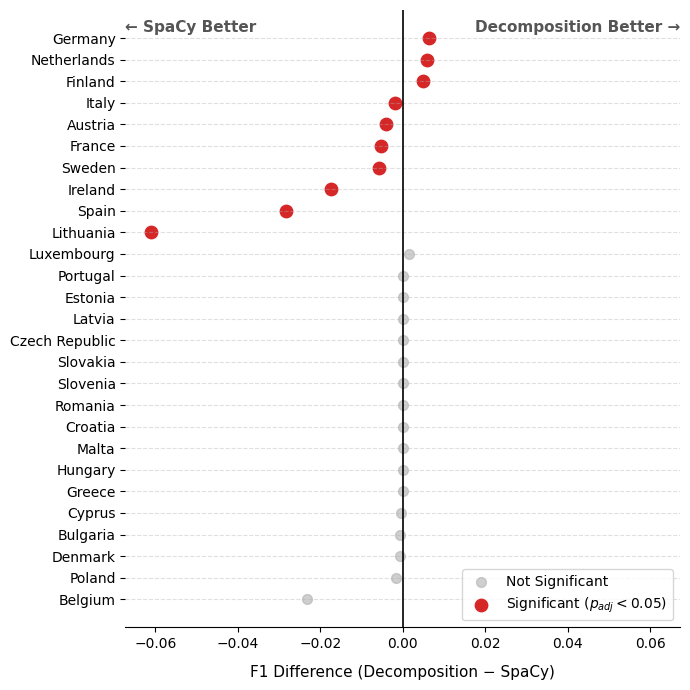

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is called 'df'
plt.figure(figsize=(7, 7))
df_sorted = df_country.sort_values('obs_diff', ascending=True).reset_index(drop=True)

# 1. Force the x-axis to be symmetric around zero
max_limit = df_sorted['obs_diff'].abs().max() * 1.1 # Add 10% padding
plt.xlim(-max_limit, max_limit)

# 2. Plot non-significant points
ns_df = df_sorted[~df_sorted['significant']]
plt.scatter(ns_df['obs_diff'], ns_df['country'], color='#b0b0b0', alpha=0.6, s=50, label='Not Significant')

# 3. Plot significant points
sig_df = df_sorted[df_sorted['significant']]
plt.scatter(sig_df['obs_diff'], sig_df['country'], color='#d62728', s=80, label='Significant ($p_{adj} < 0.05$)')

# 4. Add vertical zero line and grid
plt.axvline(0, color='black', linestyle='-', linewidth=1.2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 5. Add directional text annotations inside the plot
y_max = len(df_sorted) - 0.5 
plt.text(-max_limit, y_max, "← SpaCy Better", ha='left', va='center', 
         fontsize=11, fontweight='bold', color='#555555')
plt.text(max_limit, y_max, "Decomposition Better →", ha='right', va='center', 
         fontsize=11, fontweight='bold', color='#555555')

# 6. Styling and Labels
plt.xlabel('F1 Difference (Decomposition \u2212 SpaCy)', fontsize=11, labelpad=10)
plt.ylabel('')
plt.legend(loc='lower right', frameon=True)

# 7. Remove top/right/left spines (Pure Matplotlib substitute for seaborn.despine)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/preprocessing.png")


In [14]:
results = []
from orgpackage.config import COUNTRY_DICT
for country in sorted(data["country"].unique()):
    strata = [
        corr_table_med[corr_table_med["country"] == country][["med-r-counter-3", "med-r-counter-4"]].rename(columns={"med-r-counter-3": "none", "med-r-counter-4": "spacy"}),
        corr_table_med[corr_table_med["country"] == country][["med-r-idf-3",     "med-r-idf-4"    ]].rename(columns={"med-r-idf-3":     "none", "med-r-idf-4":     "spacy"}),
        corr_table_adm[corr_table_adm["country"] == country][["adm-r-counter-0", "adm-r-counter-1"]].rename(columns={"adm-r-counter-0": "none", "adm-r-counter-1": "spacy"}),
        corr_table_adm[corr_table_adm["country"] == country][["adm-r-idf-0",     "adm-r-idf-1"    ]].rename(columns={"adm-r-idf-0":     "none", "adm-r-idf-1":     "spacy"}),
        corr_table_edu[corr_table_edu["country"] == country][["edu-r-counter-0", "edu-r-counter-1"]].rename(columns={"edu-r-counter-0": "none", "edu-r-counter-1": "spacy"}),
        corr_table_edu[corr_table_edu["country"] == country][["edu-r-idf-0",     "edu-r-idf-1"    ]].rename(columns={"edu-r-idf-0":     "none", "edu-r-idf-1":     "spacy"}),
    ]
    strata = [s for s in strata if len(s) >= 2]
    if not strata:
        continue
    obs, p_val = stratified_permutation_test(
        strata=strata,
        exp_a="spacy",
        exp_b="none",
        n_perm=10_000,
        random_state=42,
        statistic="pooled",
    )
    country_name = COUNTRY_DICT[country]["country"]
    results.append({"country": country_name, "obs_diff": obs, "p_value": p_val})

df_country = pd.DataFrame(results)
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(df_country["p_value"], method="holm")
df_country["p_corrected"] = p_corrected
df_country["significant"] = reject

print(df_country[df_country["significant"]].sort_values("obs_diff", ascending=False))


           country  obs_diff  p_value  p_corrected  significant
2          Estonia  0.153409   0.0001       0.0027         True
14           Spain  0.071255   0.0001       0.0027         True
9          Croatia  0.045977   0.0001       0.0027         True
15         Belgium  0.035160   0.0001       0.0027         True
20          Poland  0.026037   0.0001       0.0027         True
26     Netherlands  0.013598   0.0001       0.0027         True
1          Germany  0.001393   0.0001       0.0027         True
0           France -0.001618   0.0001       0.0027         True
4   Czech Republic -0.003456   0.0001       0.0027         True
19         Denmark -0.004212   0.0001       0.0027         True
24          Greece -0.010656   0.0016       0.0240         True
22           Italy -0.018103   0.0001       0.0027         True
12         Ireland -0.051649   0.0001       0.0027         True


# 3. Methods

=== 3-method stratified test (all domains) ===
     exp_a exp_b  obs_diff  p_value
0  counter   idf -0.003808   0.0001
1  counter   llm  0.016619   0.0001
2      idf   llm  0.020427   0.0001


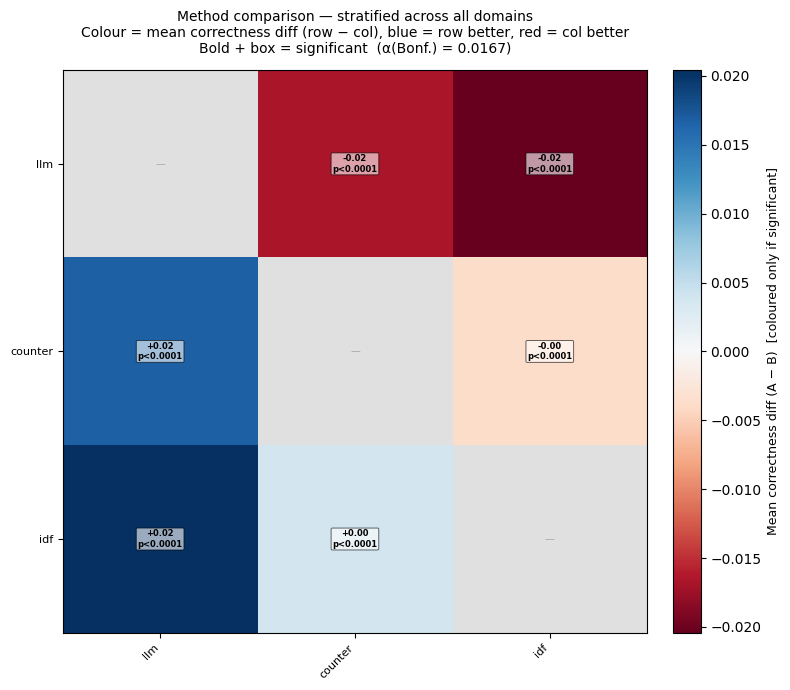


=== Expert vs all others (medical domain only) ===
            exp_a            exp_b  obs_diff  p_value  p_corrected  \
0  med-r-expert-0      med-r-llm-0 -0.008328   0.0001       0.0003   
1  med-r-expert-0  med-r-counter-4 -0.027876   0.0001       0.0003   
2  med-r-expert-0      med-r-idf-4 -0.026167   0.0001       0.0003   

   significant  
0         True  
1         True  
2         True  


In [24]:
from statsmodels.stats.multitest import multipletests
from orgpackage.tester import run_all_pairwise_tests, plot_permutation_heatmap
# ── 3-method stratified test (all 3 domains) ─────────────────────────────
strata_all = [
    corr_table_med[["med-r-llm-0", "med-r-counter-4", "med-r-idf-4"]].rename(columns={
        "med-r-llm-0": "llm", "med-r-counter-4": "counter", "med-r-idf-4": "idf"}),
    corr_table_adm[["adm-r-llm-0", "adm-r-counter-1", "adm-r-idf-1"]].rename(columns={
        "adm-r-llm-0": "llm", "adm-r-counter-1": "counter", "adm-r-idf-1": "idf"}),
    corr_table_edu[["edu-r-llm-0", "edu-r-counter-1", "edu-r-idf-1"]].rename(columns={
        "edu-r-llm-0": "llm", "edu-r-counter-1": "counter", "edu-r-idf-1": "idf"}),
]

results_all = run_all_pairwise_tests(
    strata=strata_all,
    n_perm=10_000,
    random_state=42,
    statistic="pooled",
)
print("=== 3-method stratified test (all domains) ===")
print(results_all)

plot_permutation_heatmap(
    results=results_all,
    correctness=strata_all,
    title="Method comparison — stratified across all domains",
    alpha=0.05,
    bonferroni=True,
    exp_order=["llm", "counter", "idf"],
    save_path='figures/rule_methods_heatmap.png'
)

# ── expert vs all others (medical domain only) ────────────────────────────
expert_pairs = [
    ("med-r-expert-0", "med-r-llm-0"),
    ("med-r-expert-0", "med-r-counter-4"),
    ("med-r-expert-0", "med-r-idf-4"),
]

rows = []
for exp_a, exp_b in expert_pairs:
    obs, p_val = stratified_permutation_test(
        strata=[corr_table_med[[exp_a, exp_b]]],
        exp_a=exp_a,
        exp_b=exp_b,
        n_perm=10_000,
        random_state=42,
        statistic="pooled",
    )
    rows.append({"exp_a": exp_a, "exp_b": exp_b, "obs_diff": obs, "p_value": p_val})

df_expert = pd.DataFrame(rows)
reject, p_corrected, _, _ = multipletests(df_expert["p_value"], method="holm")
df_expert["p_corrected"] = p_corrected
df_expert["significant"] = reject
print("\n=== Expert vs all others (medical domain only) ===")
print(df_expert)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


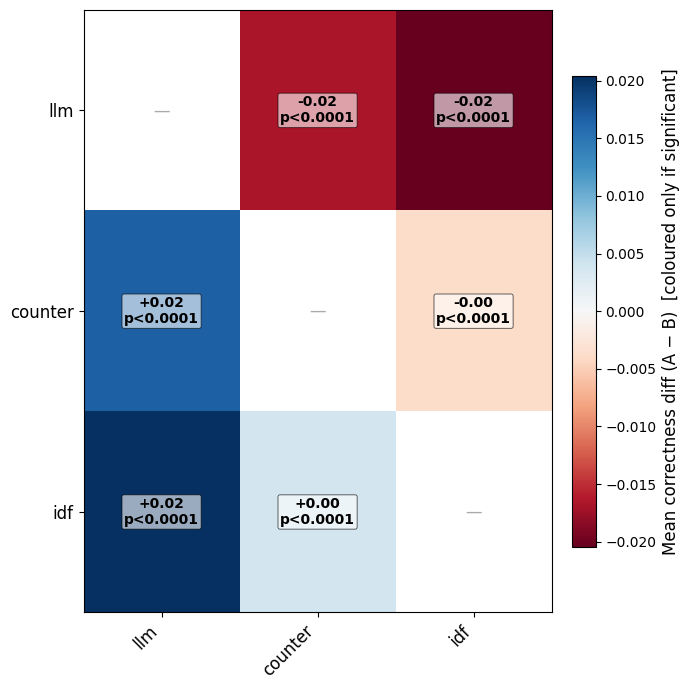

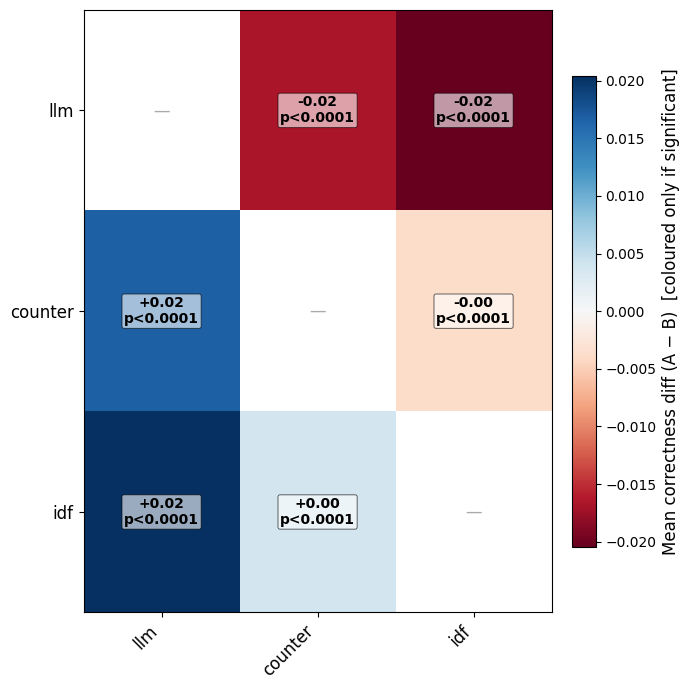

In [34]:
%reload_ext autoreload
%load_ext autoreload
%autoreload 2

plot_permutation_heatmap(
    results=results_all,
    correctness=strata_all,
    title="Method comparison — stratified across all domains",
    alpha=0.05,
    bonferroni=True,
    exp_order=["llm", "counter", "idf"],
    save_path='figures/rule_methods_heatmap.png'
)

In [16]:
results = []
for country in sorted(data["country"].unique()):

    strata = [
        corr_table_med[corr_table_med["country"] == country][["med-r-counter-4", "med-r-idf-4"]].rename(columns={"med-r-counter-4": "counter", "med-r-idf-4": "idf"}),
        corr_table_adm[corr_table_adm["country"] == country][["adm-r-counter-1", "adm-r-idf-1"]].rename(columns={"adm-r-counter-1": "counter", "adm-r-idf-1": "idf"}),
        corr_table_edu[corr_table_edu["country"] == country][["edu-r-counter-1", "edu-r-idf-1"]].rename(columns={"edu-r-counter-1": "counter", "edu-r-idf-1": "idf"}),
    ]
    strata = [s for s in strata if len(s) >= 2]

    if not strata:
        continue

    obs, p_val = stratified_permutation_test(
        strata=strata,
        exp_a="counter",
        exp_b="idf",
        n_perm=10_000,
        random_state=42,
        statistic="pooled",
    )
    country_name = COUNTRY_DICT[country]["country"]
    results.append({"country": f"{country_name}", "obs_diff": obs, "p_value": p_val})

df_country = pd.DataFrame(results)
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(df_country["p_value"], method="holm")
df_country["p_corrected"] = p_corrected
df_country["significant"] = reject

print(df_country[df_country["significant"]].sort_values("obs_diff", ascending=False))

           country  obs_diff  p_value  p_corrected  significant
26     Netherlands  0.069061   0.0001       0.0027         True
0           France  0.040448   0.0001       0.0027         True
6         Slovenia  0.038658   0.0001       0.0027         True
23         Austria  0.021819   0.0001       0.0027         True
14           Spain  0.016865   0.0001       0.0027         True
19         Denmark  0.012864   0.0001       0.0027         True
1          Germany  0.007817   0.0001       0.0027         True
20          Poland -0.017494   0.0001       0.0027         True
22           Italy -0.034855   0.0001       0.0027         True
4   Czech Republic -0.097519   0.0001       0.0027         True
12         Ireland -0.109521   0.0001       0.0027         True
21       Lithuania -0.215283   0.0001       0.0027         True


In [25]:
import lang2vec.lang2vec as l2v
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

country_to_iso3 = {
    "France":         "fra",
    "Germany":        "deu",
    "Estonia":        "est",
    "Latvia":         "lav",
    "Czech Republic": "ces",
    "Slovakia":       "slk",
    "Slovenia":       "slv",
    "Romania":        "ron",
    "Bulgaria":       "bul",
    "Croatia":        "hrv",
    "Cyprus":         "ell",
    "Malta":          "mlt",
    "Ireland":        "eng",
    "Hungary":        "hun",
    "Spain":          "spa",
    "Belgium":        "nld",
    "Luxembourg":     "ltz",
    "Finland":        "fin",
    "Sweden":         "swe",
    "Denmark":        "dan",
    "Poland":         "pol",
    "Lithuania":      "lit",
    "Italy":          "ita",
    "Austria":        "deu",
    "Greece":         "ell",
    "Portugal":       "por",
    "Netherlands":    "nld",
}

# Deduplicate languages for querying
languages = list(dict.fromkeys(country_to_iso3.values()))

# Pull all feature sets
feature_sets = ["syntax_wals", "syntax_sswl", "syntax_ethnologue", "fam", "geo"]

all_features = {}
for fs in feature_sets:
    feats = l2v.get_features(languages, fs, header=True)
    feature_names = feats["CODE"]
    for lang in languages:
        if lang not in all_features:
            all_features[lang] = {}
        all_features[lang].update(dict(zip(feature_names, feats[lang])))

df_lang = pd.DataFrame(all_features).T
df_lang.index.name = "iso3"

# Map country names to iso3 directly from country_to_iso3
df_country["iso3"] = df_country["country"].map(country_to_iso3)
print(f"Unmapped countries: {df_country[df_country['iso3'].isna()]['country'].tolist()}")

df_merged = df_country.merge(df_lang, left_on="iso3", right_index=True)
print(f"Merged shape: {df_merged.shape}")

# Replace '--' missing values, convert to numeric
df_numeric = df_merged.drop(columns=["country", "iso3", "p_value", "p_corrected", "significant"])
df_numeric = df_numeric.replace("--", np.nan)
df_numeric = df_numeric.apply(pd.to_numeric, errors="coerce")

# Spearman correlation of every feature against obs_diff
correlations = {}
for col in df_numeric.columns:
    if col == "obs_diff":
        continue
    valid = df_numeric[["obs_diff", col]].dropna()
    if len(valid) < 5 or valid[col].nunique() < 2:
        continue
    r, p = spearmanr(valid["obs_diff"], valid[col])
    correlations[col] = {"spearman_r": r, "p_value": p}

if not correlations:
    print("No valid correlations found — check df_numeric for NaNs:")
    print(df_numeric.notna().sum().sort_values().head(20))
else:
    df_corr = pd.DataFrame(correlations).T.sort_values("spearman_r", ascending=False)
    print("=== Features most correlated with counter > idf ===")
    print(df_corr.head(20))
    print("\n=== Features most correlated with idf > counter ===")
    print(df_corr.tail(20))

NameError: name 'df_country' is not defined

In [ ]:
test = l2v.get_features(["nld", "fra"], "syntax_wals", header=True)
print(type(test))
print(test.keys() if isinstance(test, dict) else test)

<class 'dict'>
dict_keys(['CODE', 'nld', 'fra'])


## 4. Corpus Analysis

In [19]:
import pandas as pd
import numpy as np
from collections import Counter
import zlib
from orgpackage.config import COUNTRY_DICT

def _shannon_entropy_from_counts(counts: Counter) -> float:
    total = sum(counts.values())
    if total == 0:
        return np.nan
    probs = np.array([c / total for c in counts.values()], dtype=float)
    return -np.sum(probs * np.log2(probs + 1e-10))

def compute_corpus_stats_overall(data: pd.DataFrame, name_col: str = "names") -> pd.DataFrame:
    """
    Compute aggregate corpus statistics from entity name strings for the entire dataset.
    Returns a DataFrame with a single row.
    """
    # ── extraction ────────────────────────────────────────────────────
    names = data[name_col].dropna().tolist()
    tokens_per_name = [n.split() for n in names]
    all_tokens = [t for tokens in tokens_per_name for t in tokens]
    all_tokens_lower = [t.lower() for t in all_tokens]

    # ── length features ───────────────────────────────────────────────
    char_lengths = [len(n) for n in names]
    token_lengths = [len(t) for t in tokens_per_name]

    # ── type-token ratio ──────────────────────────────────────────────
    n_tokens = len(all_tokens_lower)
    n_types = len(set(all_tokens_lower))
    ttr = n_types / n_tokens if n_tokens > 0 else np.nan

    # ── suffix diversity (last 3 chars of each token) ─────────────────
    suffixes = [t[-3:] for t in all_tokens_lower if len(t) >= 3]
    n_unique_suffixes = len(set(suffixes))
    suffix_diversity = n_unique_suffixes / len(suffixes) if suffixes else np.nan

    # ── prefix diversity (first 3 chars of each token) ───────────────
    prefixes = [t[:3] for t in all_tokens_lower if len(t) >= 3]
    n_unique_prefixes = len(set(prefixes))
    prefix_diversity = n_unique_prefixes / len(prefixes) if prefixes else np.nan

    # ── unigram / bigram / trigram entropies ─────────────────────────
    token_counts = Counter(all_tokens_lower)
    token_entropy = _shannon_entropy_from_counts(token_counts)

    bigrams = []
    trigrams = []
    for toks in tokens_per_name:
        if len(toks) >= 2:
            bigrams.extend(zip(toks[:-1], toks[1:]))
        if len(toks) >= 3:
            trigrams.extend(zip(toks[:-2], toks[1:-1], toks[2:]))
    
    bigram_entropy = _shannon_entropy_from_counts(Counter(bigrams)) if bigrams else np.nan
    trigram_entropy = _shannon_entropy_from_counts(Counter(trigrams)) if trigrams else np.nan

    # ── hapax legomena ratio (tokens appearing only once) ─────────────
    hapax = sum(1 for c in token_counts.values() if c == 1)
    hapax_ratio = hapax / n_types if n_types > 0 else np.nan

    # ── compression ratio ─────────────────────────────────────────────
    if names:
        concat = " \n".join(names).encode("utf-8")
        original_len = len(concat)
        if original_len > 0:
            compressed = zlib.compress(concat, level=9)
            compression_ratio = len(compressed) / original_len
        else:
            compression_ratio = np.nan
    else:
        compression_ratio = np.nan

    stats = {
        "mean_char_length":     np.mean(char_lengths) if char_lengths else np.nan,
        "std_char_length":      np.std(char_lengths) if char_lengths else np.nan,
        "mean_token_count":     np.mean(token_lengths) if token_lengths else np.nan,
        "std_token_count":      np.std(token_lengths) if token_lengths else np.nan,
        "ttr":                  ttr,
        "hapax_ratio":          hapax_ratio,
        "suffix_diversity":     suffix_diversity,
        "prefix_diversity":     prefix_diversity,
        "token_entropy":        token_entropy,
        "bigram_entropy":       bigram_entropy,
        "trigram_entropy":      trigram_entropy,
        "compression_ratio":    compression_ratio,
        "n_unique_tokens":      n_types,
        "n_total_tokens":       n_tokens,
        "n_entities":           len(names),
    }

    return pd.DataFrame([stats])

def compute_corpus_stats_per_country(data: pd.DataFrame, name_col: str = "names", country_col: str = "country") -> pd.DataFrame:
    """
    Compute per-country corpus statistics from entity name strings.
    Returns a DataFrame with one row per country.
    """
    from orgpackage.config import COUNTRY_DICT
    rows = []
    # 'country_code' is the key from your groupby (e.g., 'Q142')
    for country_code, group in data.groupby(country_col):
        # 1. Look up the actual name immediately
        country_name = COUNTRY_DICT.get(country_code, {}).get("country", country_code)
        
        names = group[name_col].dropna().tolist()
        tokens_per_name = [n.split() for n in names]
        all_tokens = [t for tokens in tokens_per_name for t in tokens]
        all_tokens_lower = [t.lower() for t in all_tokens]
        # ── length features ───────────────────────────────────────────────
        char_lengths = [len(n) for n in names]
        token_lengths = [len(t) for t in tokens_per_name]
        # ── type-token ratio ──────────────────────────────────────────────
        n_tokens = len(all_tokens_lower)
        n_types = len(set(all_tokens_lower))
        ttr = n_types / n_tokens if n_tokens > 0 else np.nan
        # ── suffix diversity (last 3 chars of each token) ─────────────────
        suffixes = [t[-3:] for t in all_tokens_lower if len(t) >= 3]
        n_unique_suffixes = len(set(suffixes))
        suffix_diversity = n_unique_suffixes / len(suffixes) if suffixes else np.nan
        # ── prefix diversity (first 3 chars of each token) ───────────────
        prefixes = [t[:3] for t in all_tokens_lower if len(t) >= 3]
        n_unique_prefixes = len(set(prefixes))
        prefix_diversity = n_unique_prefixes / len(prefixes) if prefixes else np.nan
        # ── unigram / bigram / trigram entropies ─────────────────────────
        token_counts = Counter(all_tokens_lower)
        token_entropy = _shannon_entropy_from_counts(token_counts)
        bigrams = []
        trigrams = []
        for toks in tokens_per_name:
            if len(toks) >= 2:
                bigrams.extend(zip(toks[:-1], toks[1:]))
            if len(toks) >= 3:
                trigrams.extend(zip(toks[:-2], toks[1:-1], toks[2:]))
        bigram_entropy = _shannon_entropy_from_counts(Counter(bigrams)) if bigrams else np.nan
        trigram_entropy = _shannon_entropy_from_counts(Counter(trigrams)) if trigrams else np.nan
        # ── hapax legomena ratio (tokens appearing only once) ─────────────
        hapax = sum(1 for c in token_counts.values() if c == 1)
        hapax_ratio = hapax / n_types if n_types > 0 else np.nan
        # ── compression ratio of concatenated names ──────────────────────
        if names:
            concat = " \n".join(names).encode("utf-8")
            original_len = len(concat)
            if original_len > 0:
                compressed = zlib.compress(concat, level=9)
                compression_ratio = len(compressed) / original_len
            else:
                compression_ratio = np.nan
        else:
            compression_ratio = np.nan
        rows.append({
            "country":              country_name,
            # length
            "mean_char_length":     np.mean(char_lengths) if char_lengths else np.nan,
            "std_char_length":      np.std(char_lengths) if char_lengths else np.nan,
            "mean_token_count":     np.mean(token_lengths) if token_lengths else np.nan,
            "std_token_count":      np.std(token_lengths) if token_lengths else np.nan,
            # lexical richness
            "ttr":                  ttr,
            "hapax_ratio":          hapax_ratio,
            # morphological proxies
            "suffix_diversity":     suffix_diversity,
            "prefix_diversity":     prefix_diversity,
            # frequency distributions
            "token_entropy":        token_entropy,
            "bigram_entropy":       bigram_entropy,
            "trigram_entropy":      trigram_entropy,
            # compression
            "compression_ratio":    compression_ratio,
            # counts
            "n_unique_tokens":      n_types,
            "n_total_tokens":       n_tokens,
            "n_entities":           len(names),
        })
    # Use .set_index("country") to make the names the first column/index
    return pd.DataFrame(rows)


# Run it
df_corpus = compute_corpus_stats_overall(data)
df_corpus_country = compute_corpus_stats_per_country(data, name_col="names", country_col="country")
print(df_corpus_country)

           country  mean_char_length  std_char_length  mean_token_count  \
0           France         23.391076        14.670206          3.035323   
1          Germany         26.833804        15.646136          2.751103   
2          Estonia         20.965278         8.002962          2.472222   
3           Latvia         24.251627        12.419529          3.110629   
4   Czech Republic         20.424680        11.631626          3.014369   
5         Slovakia         17.150259        10.874693          2.500864   
6         Slovenia         25.921900        14.122503          3.536148   
7          Romania         32.374207        14.726740          4.452431   
8         Bulgaria         25.850757        15.675469          3.678443   
9          Croatia         23.438776        12.378443          3.183673   
10          Cyprus         22.448633         9.800866          2.720075   
11           Malta         23.916667        11.026168          3.395833   
12         Ireland       

In [20]:
print(df_corpus_country.to_latex(
    index=False, 
    float_format="%.3f",
    column_format="lr",  # Left-align labels, Right-align values
    bold_rows=True,
    caption="Overall Corpus Statistics"
))

\begin{table}
\caption{Overall Corpus Statistics}
\begin{tabular}{lr}
\toprule
country & mean_char_length & std_char_length & mean_token_count & std_token_count & ttr & hapax_ratio & suffix_diversity & prefix_diversity & token_entropy & bigram_entropy & trigram_entropy & compression_ratio & n_unique_tokens & n_total_tokens & n_entities \\
\midrule
France & 23.391 & 14.670 & 3.035 & 2.058 & 0.330 & 0.813 & 0.056 & 0.059 & 10.065 & 11.840 & 12.718 & 0.344 & 19844 & 60066 & 19789 \\
Germany & 26.834 & 15.646 & 2.751 & 1.697 & 0.390 & 0.767 & 0.057 & 0.065 & 12.293 & 14.280 & 13.755 & 0.354 & 21637 & 55487 & 20169 \\
Estonia & 20.965 & 8.003 & 2.472 & 0.763 & 0.545 & 0.820 & 0.313 & 0.435 & 6.556 & 7.677 & 6.190 & 0.393 & 194 & 356 & 144 \\
Latvia & 24.252 & 12.420 & 3.111 & 1.678 & 0.387 & 0.732 & 0.198 & 0.253 & 8.771 & 10.124 & 9.747 & 0.324 & 1110 & 2868 & 922 \\
Czech Republic & 20.425 & 11.632 & 3.014 & 1.637 & 0.256 & 0.732 & 0.079 & 0.078 & 10.018 & 11.584 & 11.951 & 0.309 & 13422 

In [22]:
df_vertical = df_corpus.T.reset_index()
df_vertical.columns = ["Metric", "Value"]

# Generate the LaTeX string
latex_str = df_vertical.to_latex(
    index=False, 
    float_format="%.3f",
    column_format="lr",  # Left-align labels, Right-align values
    bold_rows=True,
    caption="Overall Corpus Statistics"
)

print(latex_str)

\begin{table}
\caption{Overall Corpus Statistics}
\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
mean_char_length & 23.869 \\
std_char_length & 14.096 \\
mean_token_count & 3.138 \\
std_token_count & 1.950 \\
ttr & 0.262 \\
hapax_ratio & 0.719 \\
suffix_diversity & 0.029 \\
prefix_diversity & 0.029 \\
token_entropy & 13.574 \\
bigram_entropy & 16.193 \\
trigram_entropy & 16.597 \\
compression_ratio & 0.341 \\
n_unique_tokens & 150056.000 \\
n_total_tokens & 572685.000 \\
n_entities & 182519.000 \\
\bottomrule
\end{tabular}
\end{table}



In [23]:
# Merge corpus stats into df_merged
# Step 1: map country code -> name using COUNTRY_DICT
data["country_name"] = data["country"].map(lambda x: COUNTRY_DICT[x]["country"])

# Step 2: compute corpus stats using country_name
df_corpus = compute_corpus_stats_per_country(data, name_col="names", country_col="country_name")
print(df_corpus)

# Step 3: map country name -> iso3 for merging with df_lang
df_corpus["iso3"] = df_corpus.index.map(country_to_iso3)
print(df_corpus["iso3"].isna().sum(), "unmapped countries")


df_merged2 = df_merged.merge(df_corpus, left_on="country", right_index=True)

df_numeric2 = df_merged2.drop(
    columns=["country", "p_value", "p_corrected", "significant"],
    errors="ignore"
)
# Drop any iso3 columns (may be iso3_x, iso3_y after merge)
df_numeric2 = df_numeric2.drop(
    columns=[c for c in df_numeric2.columns if "iso3" in c],
    errors="ignore"
)
df_numeric2 = df_numeric2.replace("--", np.nan)
df_numeric2 = df_numeric2.apply(pd.to_numeric, errors="coerce")

correlations = {}
for col in df_numeric2.columns:
    if col == "obs_diff":
        continue
    valid = df_numeric2[["obs_diff", col]].dropna()
    if len(valid) < 5 or valid[col].nunique() < 2:
        continue
    r, p = spearmanr(valid["obs_diff"], valid[col])
    correlations[col] = {"spearman_r": r, "p_value": p}

df_corr = pd.DataFrame(correlations).T.sort_values("spearman_r", ascending=False)
print("=== Top correlates with counter > idf ===")
print(df_corr.head(20))
print("\n=== Top correlates with idf > counter ===")
print(df_corr.tail(20))

           country  mean_char_length  std_char_length  mean_token_count  \
0          Austria         22.520015        14.160546          2.498180   
1          Belgium         23.576020        14.119373          2.866502   
2         Bulgaria         25.850757        15.675469          3.678443   
3          Croatia         23.438776        12.378443          3.183673   
4           Cyprus         22.448633         9.800866          2.720075   
5   Czech Republic         20.424680        11.631626          3.014369   
6          Denmark         17.679245         8.770940          2.226415   
7          Estonia         20.965278         8.002962          2.472222   
8          Finland         18.245176         8.546857          2.001072   
9           France         23.391076        14.670206          3.035323   
10         Germany         26.833804        15.646136          2.751103   
11          Greece         28.465201        12.188976          3.509158   
12         Hungary       

NameError: name 'country_to_iso3' is not defined

## 5. Performance–feature correlations

We now correlate **per-country, per-experiment performance** (mean correctness) with:
- **Linguistic features** from `lang2vec` (per language / iso3 code)
- **Corpus-derived features** computed **only on positive-class entities** (any target label = 1), aggregated per country.

This replaces the earlier correlation that used the *difference* between counter and IDF; here, each row is a `(experiment, country)` pair with its own accuracy.

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from orgpackage.config import COUNTRY_DICT

# ------------------------------------------------------------------
# 5.1 Corpus metrics on positive-class entities only (train+test proxy)
# ------------------------------------------------------------------
class_cols = [
    "hospital",
    "university_hospital",
    "local_government",
    "primary_school",
    "secondary_school",
]

if "country" not in data.columns:
    data["country"] = data["country"].map(lambda x: COUNTRY_DICT[x]["country"])

positives = data[data[class_cols].sum(axis=1) > 0].copy()

df_corpus_pos = compute_corpus_stats_per_country(
    positives,
    name_col="names",
    country_col="country",
)

# Reset index so the country name becomes a regular column for merging
df_corpus_pos = df_corpus_pos.reset_index()          # index → "country_name" column
df_corpus_pos["iso3"] = df_corpus_pos["country"].map(country_to_iso3)

# ------------------------------------------------------------------
# 5.2 Build per-(experiment, country) performance table
# ------------------------------------------------------------------
rows = []
for domain_key, corr in correctness_tables.items():
    for exp_col in corr.columns:
        if exp_col == "country":
            continue
        grouped = corr.groupby("country")[exp_col].mean()
        for country_code, acc in grouped.items():
            country_name = COUNTRY_DICT[country_code]["country"]
            rows.append(
                {
                    "domain": domain_key,
                    "exp_id": exp_col,
                    "country_code": country_code,
                    "country": country_name,
                    "accuracy": acc,
                }
            )

df_perf = pd.DataFrame(rows)
df_perf["iso3"] = df_perf["country"].map(country_to_iso3)

# ------------------------------------------------------------------
# 5.3 Merge performance with language + corpus features
# ------------------------------------------------------------------
perf_lang = df_perf.merge(df_lang, left_on="iso3", right_index=True, how="left")

# FIX: merge on the named column now that df_corpus_pos index was reset
perf_all = perf_lang.merge(
    df_corpus_pos,
    left_on="country",
    right_on="country",       # ← named column, not right_index
    how="left",
    suffixes=("_lang", "_corp"),
)

# ------------------------------------------------------------------
# 5.4 Spearman correlations: F1 vs all features
# ------------------------------------------------------------------
drop_cols = ["domain", "exp_id", "country_code", "country", "iso3"]

df_numeric = perf_all.drop(columns=[c for c in drop_cols if c in perf_all.columns])
df_numeric = df_numeric.replace("--", np.nan)
df_numeric = df_numeric.apply(pd.to_numeric, errors="coerce")

correlations = {}
for col in df_numeric.columns:
    if col == "accuracy":
        continue
    valid = df_numeric[["accuracy", col]].dropna()
    if len(valid) < 5 or valid[col].nunique() < 2:
        continue
    r, p = spearmanr(valid["accuracy"], valid[col])
    correlations[col] = {"spearman_r": r, "p_value": p}

if not correlations:
    print("No valid correlations found — check perf_all for NaNs.")
else:
    df_corr_perf = (
        pd.DataFrame(correlations)
        .T
        .sort_values("spearman_r", ascending=False)
        .astype(float)
    )

    # Filter significant, take top/bottom 10
    df_sig = df_corr_perf[df_corr_perf["p_value"] < 0.05]
    df_display = pd.concat([df_sig.head(10), df_sig.tail(10)])

    # Human-readable labels and feature type
    FEATURE_META = {
        "S_POSSESSOR_AFTER_NOUN":   ("Possessor after noun",           "Syntax"),
        "S_POSSESSOR_BEFORE_NOUN":  ("Possessor before noun",          "Syntax"),
        "S_ADJECTIVE_AFTER_NOUN":   ("Adjective after noun",           "Syntax"),
        "n_total_tokens":           ("Total tokens in corpus",         "Corpus size"),
        "n_entities":               ("Number of entities",             "Corpus size"),
        "n_unique_tokens":          ("Unique tokens",                  "Corpus size"),
        "trigram_entropy":          ("Trigram entropy",                "Corpus lexical"),
        "bigram_entropy":           ("Bigram entropy",                 "Corpus lexical"),
        "ttr":                      ("Type-token ratio (TTR)",         "Corpus lexical"),
        "compression_ratio":        ("Compression ratio",              "Corpus lexical"),
        "prefix_diversity":         ("Prefix diversity",               "Corpus morphol."),
        "suffix_diversity":         ("Suffix diversity",               "Corpus morphol."),
        "F_Indo-European":          ("Indo-European family",           "Language family"),
        "F_North_Germanic":         ("North Germanic subfamily",       "Language family"),
        "F_East_Scandinavian":      ("East Scandinavian subfamily",    "Language family"),
        "F_Macro-Dutch":            ("Macro-Dutch subfamily",          "Language family"),
        "F_West_Germanic":          ("West Germanic subfamily",        "Language family"),
        "F_South-Western_Slavic":   ("South-Western Slavic subfamily", "Language family"),
        "F_Molise-SKB":             ("Molise-SKB subfamily",           "Language family"),
        "F_Franconian":             ("Franconian subfamily",           "Language family"),
    }

    def fmt_p(p):
        if p < 0.001: return r"$<$0.001$^{***}$"
        if p < 0.01:  return rf"{p:.3f}$^{{**}}$"
        if p < 0.05:  return rf"{p:.3f}$^{{*}}$"
        return f"{p:.3f}"

    def sig_stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        return "*"

    lines = []
    lines.append(r"\begin{sidewaystable}")
    lines.append(r"\centering")
    lines.append(
        r"\caption{Spearman rank correlations ($\rho$) between country-level F1 and "
        r"linguistic/corpus features. $\rho > 0$: higher feature value associates with "
        r"higher F1; $\rho < 0$: the opposite. Only significant results ($p < .05$) shown. "
        r"$^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$.}"
    )
    lines.append(r"\label{tab:spearman_f1}")
    lines.append(r"\begin{tabular}{llrr}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Feature} & \textbf{Type} & $\boldsymbol{\rho}$ & \textbf{$p$} \\")
    lines.append(r"\midrule")
    lines.append(r"\multicolumn{4}{l}{\textit{Positively correlated with F1}} \\[2pt]")

    top = df_sig.head(10)
    for feat, row in top.iterrows():
        label, ftype = FEATURE_META.get(feat, (feat.replace("_", " "), "—"))
        lines.append(rf"{label} & {ftype} & ${row['spearman_r']:+.3f}$ & {fmt_p(row['p_value'])} \\")

    lines.append(r"\midrule")
    lines.append(r"\multicolumn{4}{l}{\textit{Negatively correlated with F1}} \\[2pt]")

    bot = df_sig.tail(10)
    for feat, row in bot.iterrows():
        label, ftype = FEATURE_META.get(feat, (feat.replace("_", " "), "—"))
        lines.append(rf"{label} & {ftype} & ${row['spearman_r']:+.3f}$ & {fmt_p(row['p_value'])} \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{sidewaystable}")

    print("\n".join(lines))

/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_1046/1561059569.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_numeric.replace("--", np.nan)


\begin{sidewaystable}
\centering
\caption{Spearman rank correlations ($\rho$) between country-level F1 and linguistic/corpus features. $\rho > 0$: higher feature value associates with higher F1; $\rho < 0$: the opposite. Only significant results ($p < .05$) shown. $^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$.}
\label{tab:spearman_f1}
\begin{tabular}{llrr}
\toprule
\textbf{Feature} & \textbf{Type} & $\boldsymbol{\rho}$ & \textbf{$p$} \\
\midrule
\multicolumn{4}{l}{\textit{Positively correlated with F1}} \\[2pt]
Possessor after noun & Syntax & $+0.389$ & $<$0.001$^{***}$ \\
Total tokens in corpus & Corpus size & $+0.186$ & $<$0.001$^{***}$ \\
Number of entities & Corpus size & $+0.182$ & $<$0.001$^{***}$ \\
Trigram entropy & Corpus lexical & $+0.178$ & $<$0.001$^{***}$ \\
Unique tokens & Corpus size & $+0.161$ & $<$0.001$^{***}$ \\
Indo-European family & Language family & $+0.137$ & $<$0.001$^{***}$ \\
North Germanic subfamily & Language family & $+0.137$ & $<$0.001$^{***}$ \\
East Scandina

## 6. Word Coverages

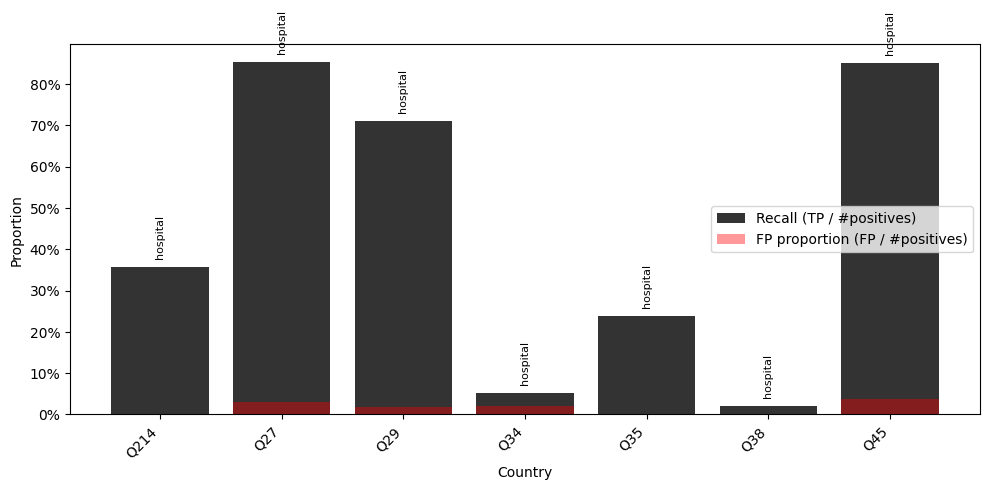

In [4]:
import matplotlib.pyplot as plt
from orgpackage.aux import load_experiments
from orgpackage.tester import build_word_coverage_table
from orgpackage.plotter import plot_word_recall_per_country
%aimport orgpackage.tester
%aimport orgpackage.plotter

exp_ids_of_interest = ["med-r-idf-4", "adm-r-idf-1", "edu-r-idf-1"]
experiments = load_experiments("./results/experiments.csv")

coverage_df = build_word_coverage_table(experiments, tests, exp_ids_of_interest)

example_exp = "med-r-idf-4"
example_cls = "hospital"

top_word = (
    coverage_df[
        (coverage_df["exp_id"] == example_exp)
        & (coverage_df["cls"] == example_cls)
    ]
    .sort_values("total", ascending=False)["word"]
    .iloc[0]
)

plot_word_recall_per_country(
    coverage_df,
    tests=tests,
    exp_id=example_exp,
    cls=example_cls,
    word=top_word
)

Figure saved to figures/med_coverage_top.png


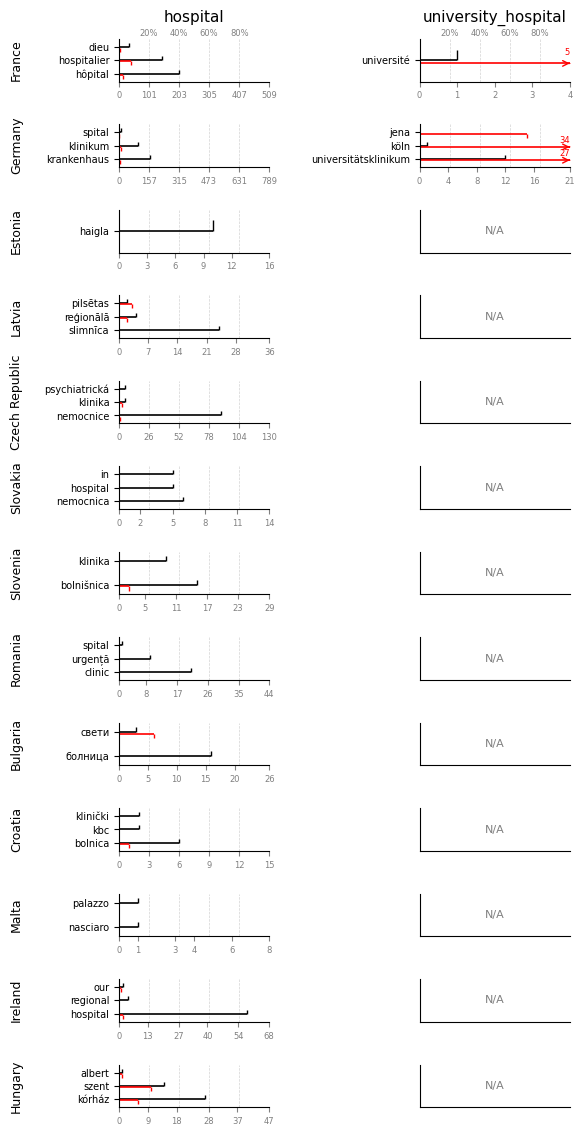

Figure saved to figures/med_coverage_bottom.png


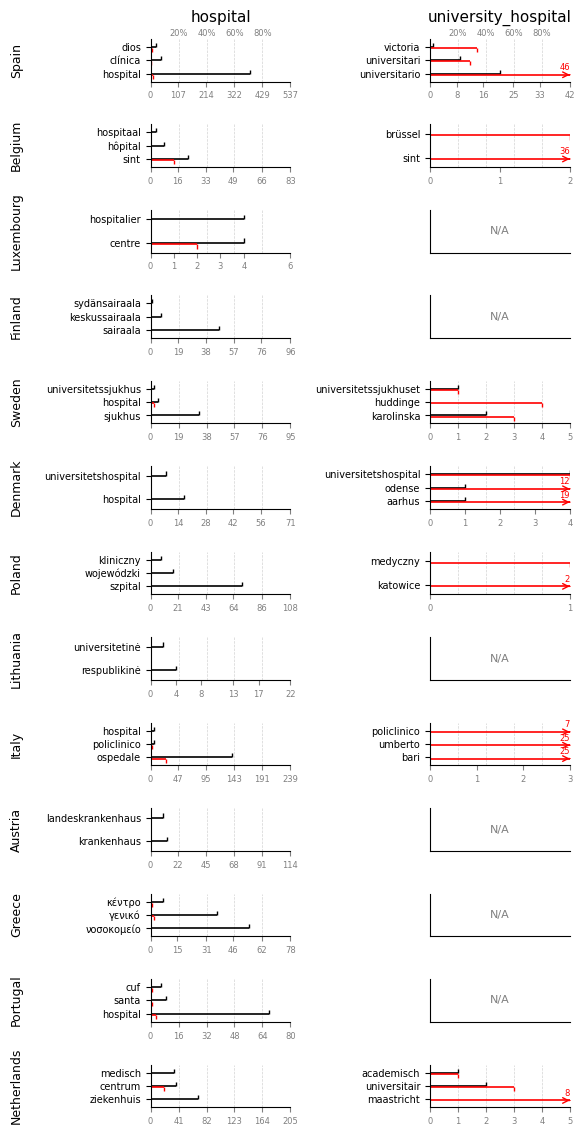

In [91]:



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%aimport orgpackage.tester


from orgpackage.plotter import plot_word_coverage_all_countries


# ── Example usage ─────────────────────────────────────────────────────────────

plot_word_coverage_all_countries(
    coverage_df,
    tests,                 # pass your tests dict here
    exp_id="med-r-idf-4",
    top_k_words=6,
    output_path="figures/med_coverage.png"
)

Figure saved to figures/edu_coverage_top.png


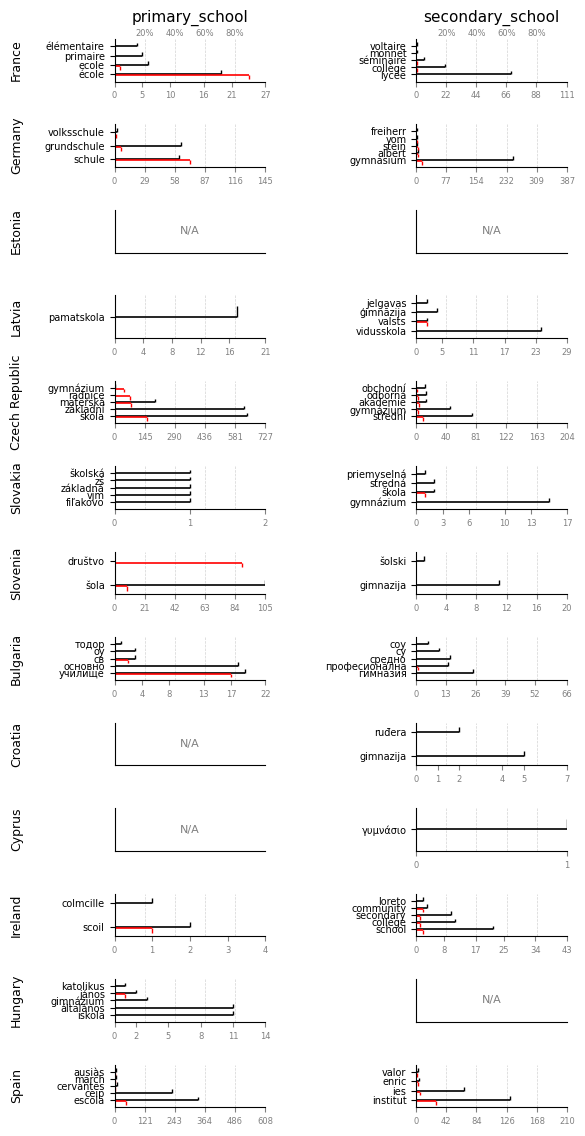

Figure saved to figures/edu_coverage_bottom.png


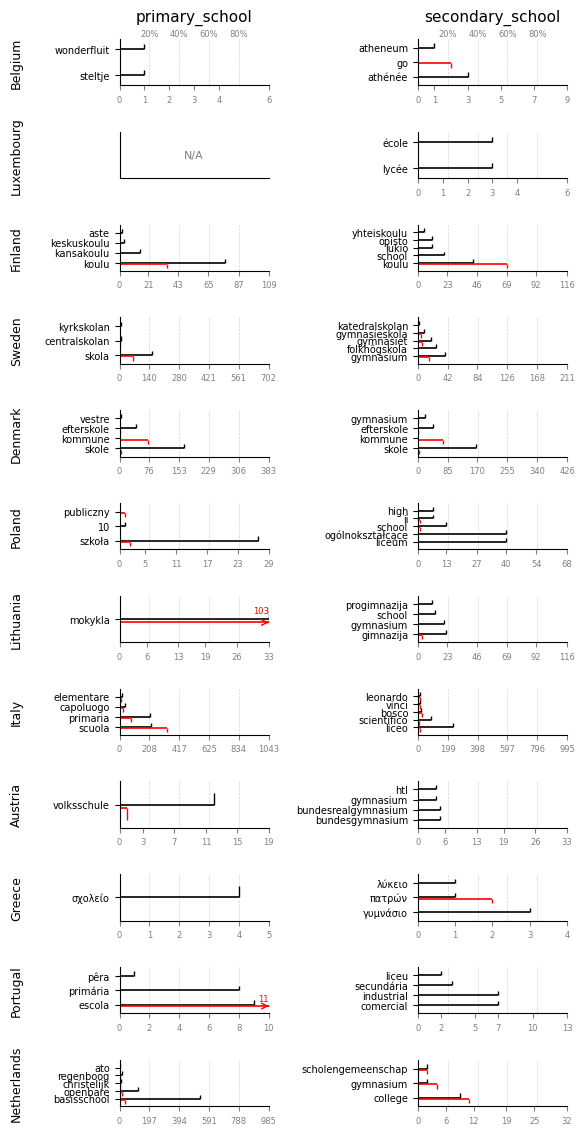

In [92]:
plot_word_coverage_all_countries(
    coverage_df,
    tests,               
    exp_id="edu-r-idf-1",
    top_k_words=6,

    output_path="figures/edu_coverage.png"
)

Figure saved to figures/adm_coverage_top.png


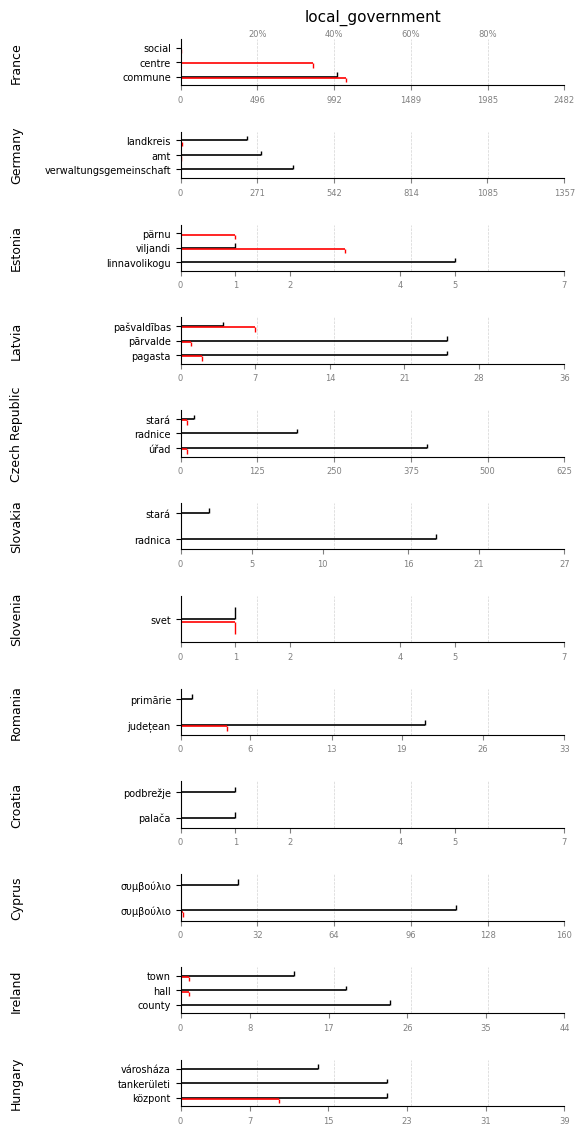

Figure saved to figures/adm_coverage_bottom.png


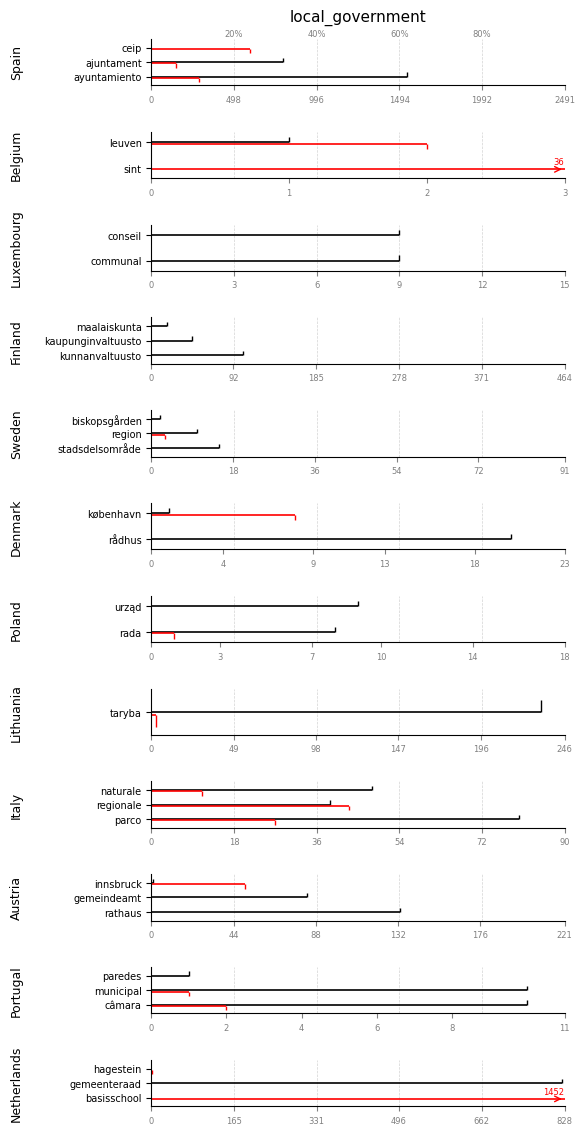

In [93]:



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%aimport orgpackage.tester


from orgpackage.plotter import plot_word_coverage_all_countries


# ── Example usage ─────────────────────────────────────────────────────────────

plot_word_coverage_all_countries(
    coverage_df,
    tests,                 # pass your tests dict here
    exp_id="adm-r-idf-1",
    top_k_words=6,

    output_path="figures/adm_coverage.png"
)

In [6]:
from orgpackage.config import DOMAIN_CLASSES_CORR, COUNTRY_DICT
import pandas as pd

def get_coverage_markdown_summary(coverage_df, tests, exp_id, top_k_words=None):
    """
    Generates a Markdown text summary of coverage and FP percentages per country/class.
    Format:
    **Country / Class** - keyword1 (Recall: X%, FP: Y%), keyword2 (Recall: ...), ...
    """
    df = coverage_df[coverage_df["exp_id"] == exp_id].copy()
    if df.empty:
        return "No data found for this exp_id."
        
    domain = df["domain"].iloc[0]
    classes = DOMAIN_CLASSES_CORR[domain]    
    test_df = tests[domain]
    
    countries = sorted(df["country"].unique())
    markdown_lines = []
    
    for country in countries:
        # Resolve Human Readable Country Name
        country_meta = COUNTRY_DICT.get(country, {})
        country_name = country_meta.get("country", country)
        
        df_country_test = test_df[test_df["country"] == country]
        df_c = df[df["country"] == country]
        
        for cls in classes:
            df_cls = df_c[df_c["cls"] == cls].copy()
            
            # Identify the denominator: Total true positives for this class in this country
            df_country_cls = df_country_test[df_country_test[cls] == 1] if not df_country_test.empty else pd.DataFrame()
            denom_pos = float(len(df_country_cls))
            
            # Skip if N/A
            if df_country_test.empty or denom_pos <= 0 or df_cls.empty:
                continue
                
            # Filter and sort
            df_cls = df_cls.sort_values("total", ascending=False)
            if top_k_words is not None:
                df_cls = df_cls.head(top_k_words)
                
            if df_cls.empty:
                continue
                
            keywords_stats = []
            for _, row in df_cls.iterrows():
                word = row["word"]
                tp = row["tp"]
                fp = row["fp"]
                
                # Math identically matching the plots
                recall_pct = (tp / denom_pos * 100) if denom_pos > 0 else 0.0
                fp_pct = (fp / denom_pos * 100) if denom_pos > 0 else 0.0
                
                # Exclude completely non-performing words
                if tp == 0 and fp == 0:
                    continue
                    
                keywords_stats.append(f"{word} (Cov: {recall_pct:.1f}%, FP: {fp_pct:.1f}%)")
            
            if keywords_stats:
                line = f"**{country_name} / {cls}** - " + "; ".join(keywords_stats)
                markdown_lines.append(line)
                
    return "\n".join(markdown_lines)


summary_text = get_coverage_markdown_summary(coverage_df, tests, exp_id="edu-r-idf-1", top_k_words=6)
print(summary_text)



**France / primary_school** - école (Cov: 70.4%, FP: 88.9%); ecole (Cov: 22.2%, FP: 3.7%); primaire (Cov: 18.5%, FP: 0.0%); élémentaire (Cov: 14.8%, FP: 0.0%)
**France / secondary_school** - lycée (Cov: 63.1%, FP: 0.0%); collège (Cov: 18.9%, FP: 0.9%); séminaire (Cov: 5.4%, FP: 0.9%); monnet (Cov: 0.9%, FP: 0.0%); voltaire (Cov: 0.9%, FP: 0.0%)
**Germany / primary_school** - schule (Cov: 42.8%, FP: 50.3%); grundschule (Cov: 44.1%, FP: 4.1%); volksschule (Cov: 1.4%, FP: 0.7%)
**Germany / secondary_school** - gymnasium (Cov: 64.1%, FP: 3.6%); albert (Cov: 1.3%, FP: 1.6%); stein (Cov: 0.5%, FP: 1.0%); vom (Cov: 0.5%, FP: 0.5%); freiherr (Cov: 0.5%, FP: 0.0%)
**Latvia / primary_school** - pamatskola (Cov: 81.0%, FP: 0.0%)
**Latvia / secondary_school** - vidusskola (Cov: 82.8%, FP: 0.0%); valsts (Cov: 6.9%, FP: 6.9%); ģimnāzija (Cov: 13.8%, FP: 0.0%); jelgavas (Cov: 6.9%, FP: 0.0%)
**Czech Republic / primary_school** - škola (Cov: 87.6%, FP: 21.7%); základní (Cov: 86.1%, FP: 0.6%); mateřská

In [3]:
from orgpackage.aux import load_experiments
import pandas as pd

# 1. Load the results from the experiments file
exps_df = load_experiments("results/experiments.csv")

# 2. Define the experiment ID mappings for each category
# Grouped to align med-r-counter-4 with the -1 variants of other domains
experiment_groups = {
    "expert": ["med-r-expert-0"],
    "llm":     ["med-r-llm-0",     "adm-r-llm-0",     "edu-r-llm-0"],
    "counter": ["med-r-counter-4", "adm-r-counter-1", "edu-r-counter-1"],
    "idf":     ["med-r-idf-4",     "adm-r-idf-1",     "edu-r-idf-1"]
}

# 3. Extract the F1 scores and align them by domain
summary_data = {}
for category, ids in experiment_groups.items():
    # Filter by ID
    subset = exps_df[exps_df['ID'].isin(ids)]
    # Create a Series indexed by Domain for this category
    summary_data[category] = subset.set_index('Domain')['F1']

# 4. Build and format the final DataFrame
summary_table = pd.DataFrame(summary_data).T
summary_table = summary_table[["medical", "administrative", "education"]] # Order columns
summary_table['Mean F1'] = summary_table.mean(axis=1)

print("Mean F1 scores per domain and category:")
display(summary_table)


Mean F1 scores per domain and category:


Domain,medical,administrative,education,Mean F1
expert,0.148029,NaN,NaN,0.148029
llm,0.372017,0.713588,0.338022,0.474542
counter,0.486180,0.832702,0.615246,0.644710
idf,0.612678,0.800033,0.687306,0.700006


In [4]:
from orgpackage.aux import load_experiments
import pandas as pd

# 1. Load the results from the experiments file
exps_df = load_experiments("results/experiments.csv")

# 2. Define the experiment ID mappings for each category
# Grouped to align med-r-counter-4 with the -1 variants of other domains
experiment_groups = {
    "roberta":  ["med-n-0-0", "edu-n-0-0", "adm-n-0-0"],
    "bge":      ["med-n-0-1", "edu-n-0-1", "adm-n-0-1"],
    "mdeberta": ["med-n-0-2", "edu-n-0-2", "adm-n-0-2"],
    "minilm":   ["med-n-0-3", "edu-n-0-3", "adm-n-0-3"],
}


# 3. Extract the F1 scores and align them by domain
summary_data = {}
for category, ids in experiment_groups.items():
    # Filter by ID
    subset = exps_df[exps_df['ID'].isin(ids)]
    # Create a Series indexed by Domain for this category
    summary_data[category] = subset.set_index('Domain')['F1']

# 4. Build and format the final DataFrame
summary_table = pd.DataFrame(summary_data).T
summary_table = summary_table[["medical", "administrative", "education"]] # Order columns
summary_table['Mean F1'] = summary_table.mean(axis=1)

print("Mean F1 scores per domain and category:")
display(summary_table)


Mean F1 scores per domain and category:


Domain,medical,administrative,education,Mean F1
roberta,0.440823,0.767278,0.473872,0.560657
bge,0.265277,0.772669,0.497835,0.511927
mdeberta,0.476352,0.674289,0.447585,0.532742
minilm,0.123156,0.527614,0.241515,0.297428
